In [ ]:
import sys
sys.path.insert(0, '..')
from dependencies import *

In [2]:
# -----------------------------
# Load TRFs (h NDVars)
# -----------------------------
encoder_log_trf = []
encoder_onset_trf = []
decoder_log_trf = []
decoder_onset_trf = []

universal_encoder_log_trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-envelope_log.pickle')
universal_encoder_onset_trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-envelope_onset.pickle')

for subject in SUBJECTS:
    encoder_log_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} envelope_log.pickle').h)
    encoder_onset_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} envelope_onset.pickle').h)
    decoder_log_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-envelope_log.pickle').h)
    decoder_onset_trf.append(eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-envelope_onset.pickle').h)

# Configure matplotlib style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
plt.rcParams.update(RC)

# --- Parameters ---
times = [0.04, 0.14, 0.24]
times_log = [0.04, 0.14, 0.24]
times_onset = [0.05, 0.2, 0.32]
time_labels = ['%d ms' % (t*1000) for t in times_log]

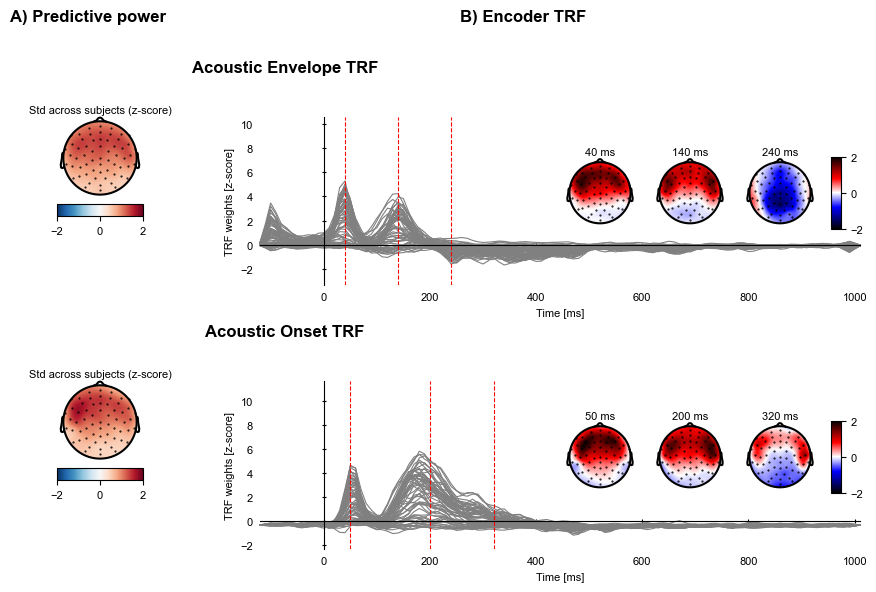

In [3]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Encoder TRFs and subject lists
# ------------------------------------------------
encoder_trfs = {
    'log': universal_encoder_log_trf,
    'onset': universal_encoder_onset_trf
}

all_subjects_dict = {
    'log': encoder_log_trf,
    'onset': encoder_onset_trf
}

times_dict = {
    'log': times_log,
    'onset': times_onset
}

# ------------------------------------------------
# Compute variability across subjects
# ------------------------------------------------
variability_maps = {}
mean_trfs = {}
for trf_type in ['log', 'onset']:
    subjects = all_subjects_dict[trf_type]
    subject_ndvars = []
    for sub in subjects:
        if isinstance(sub, eelbrain.NDVar):
            subject_ndvars.append(sub)
        elif isinstance(sub, tuple):
            subject_ndvars.append(sub[0])
        else:
            raise ValueError(f"Unexpected subject type: {type(sub)}")
    stacked = eelbrain.combine(subject_ndvars)
    
    # Compute mean and std across subjects
    mean_ndvar = stacked.mean('case')
    std_ndvar = stacked.std('case')
    
    # Z-score normalization
    z_mean = (mean_ndvar - mean_ndvar.mean()) / std_ndvar.mean()  # normalize by overall mean/std
    z_std = std_ndvar / std_ndvar.mean()
    
    mean_trfs[trf_type] = z_mean
    variability_maps[trf_type] = z_std

# ------------------------------------------------
# Figure setup
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.96, 'A) Predictive power', fontsize=12, fontweight='bold')
fig.text(0.50, 0.96, 'B) Encoder TRF', fontsize=12, fontweight='bold')

# Layout parameters
left_col = 0.05
right_col = 0.30
row_height = 0.40
gap_row = 0.04
width_var = 0.18
width_butterfly = 0.60
height_topo = 0.12
width_topo = 0.10
gap_topo = 0.005  # decreased space between topomaps

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for row_idx, trf_type in enumerate(['log', 'onset']):
    trf = mean_trfs[trf_type]             # already z-scored
    times = times_dict[trf_type]
    var_ndvar = variability_maps[trf_type]  # already normalized

    # Vertical position for this row
    bottom_row = 0.52 - row_idx*(row_height + gap_row)

    # ---------------------
    # Row-level title (centered above both left and right)
    # ---------------------
    left_edge = left_col
    right_edge = right_col + width_butterfly
    type_model = f'Acoustic Envelope' if trf_type == 'log' else f'Acoustic Onset'
    fig.text((left_edge + right_edge)/2 -0.15, bottom_row + row_height - 0.05,
             f'{type_model} TRF', fontsize=12, fontweight='bold',
             ha='center', va='bottom')

    # ---------------------
    # Variability topomap (left)
    # ---------------------
    ax_var = fig.add_axes([left_col, bottom_row + (row_height - height_topo)/2, width_var, height_topo*1.2])
    eelbrain.plot.Topomap(
        var_ndvar,
        axes=ax_var,
        axtitle='Std across subjects (z-score)',
        cmap='RdBu_r',
        clip='circle',
        vmax=None
    )
    # Colorbar
    im_var = ax_var.get_images()[0]
    cbar_ax = fig.add_axes([
        ax_var.get_position().x0,
        ax_var.get_position().y0 - 0.025,
        ax_var.get_position().width,
        0.02
    ])
    fig.colorbar(im_var, cax=cbar_ax, orientation='horizontal')

    # ---------------------
    # Butterfly TRF (right)
    # ---------------------
    ax_butterfly = fig.add_axes([right_col, bottom_row, width_butterfly, row_height*0.7])
    eelbrain.plot.Butterfly(
        trf,
        axes=ax_butterfly,
        linewidth=0.8,
        color='0.5',
        ylabel='TRF weights [z-score]',
        frame='t'
    )
    ax_butterfly.set_xlim(trf.time[0], trf.time[-1])
    y_lim = [trf.x.min(), trf.x.max()]
    ax_butterfly.set_ylim(y_lim[0]*2, y_lim[1]*2)

    # Add vertical red lines for the latency times
    for t in times:
        ax_butterfly.axvline(t, color='r', linestyle='--', linewidth=0.8)

    # ---------------------
    # Latency topomaps (top-right, above butterfly)
    # ---------------------
    n_topos = len(times)
    butterfly_pos = ax_butterfly.get_position()
    bottom_topos = butterfly_pos.y0 + 0.3*butterfly_pos.height + 0.01
    left_start = butterfly_pos.x0 + butterfly_pos.width - (n_topos*width_topo + (n_topos-1)*gap_topo)

    topomap_axes = []
    for i, t in enumerate(times):
        ax_topo = fig.add_axes([
            left_start + i*(width_topo + gap_topo) - i*0.015,
            bottom_topos,
            width_topo,
            height_topo
        ])
        topo_trf = trf.sub(time=t)
        eelbrain.plot.Topomap(
            topo_trf,
            axes=ax_topo,
            axtitle=f"{int(t*1000)} ms",
            clip='circle',
            vmax=None
        )
        topomap_axes.append(ax_topo)

    # ---------------------
    # Add vertical colorbar to the right of the topomaps
    # ---------------------
    im_topo = topomap_axes[-1].get_images()[0]
    pos = topomap_axes[-1].get_position()
    cbar_ax = fig.add_axes([
        pos.x0 + pos.width + 0.015,  # just to the right
        bottom_topos,
        0.01,                        # vertical bar width
        height_topo                    # same height as topomaps
    ])
    fig.colorbar(im_topo, cax=cbar_ax, orientation='vertical')

plt.show()
